In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [3]:
data = fetch_ucirepo(id=183)

X = data.data.features
y = data.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1994, 127)
y shape: (1994, 1)


In [4]:
X.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?


In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 127 entries, state to PolicBudgPerPop
dtypes: float64(99), int64(2), str(26)
memory usage: 1.9 MB


In [6]:
y.head()

,ViolentCrimesPerPop
0,0.20
1,0.67
2,0.43
3,0.12
4,0.03


In [8]:
X.select_dtypes(include="object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_9128\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['county', 'community', 'communityname', 'OtherPerCap', 'LemasSwornFT',
       'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop',
       'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
       'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
       'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
       'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg',
       'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop'],
      dtype='str')

In [9]:
# Replace '?' with missing values
X = X.replace("?", np.nan)

# Remove non-predictive columns
drop_cols = ["state", "county", "community", "communityname", "fold"]
X = X.drop(columns=drop_cols, errors="ignore")

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Convert target to numeric
y = y.apply(pd.to_numeric, errors="coerce").squeeze()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Median imputation, fitted ONLY on training data
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Missing values in train:", X_train.isna().sum().sum())
print("Missing values in test:", X_test.isna().sum().sum())

Training set: (1595, 122)
Testing set: (399, 122)
Missing values in train: 0
Missing values in test: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature engineering
X_train["SocioEconomicStress"] = X_train[
    ["PctUnemployed", "PctPopUnderPov", "PctNotHSGrad"]
].mean(axis=1)

X_test["SocioEconomicStress"] = X_test[
    ["PctUnemployed", "PctPopUnderPov", "PctNotHSGrad"]
].mean(axis=1)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scale training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (1595, 123)
Scaled testing data: (399, 123)


In [12]:
print("Dataset shape:", X.shape)

print("\nData types:")
print(X.dtypes.value_counts())

print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget statistics:")
print(y.describe())

Dataset shape: (1994, 122)

Data types:
float64    122
Name: count, dtype: int64

Missing values:
LemasSwFTFieldPerPop    1675
LemasSwFTFieldOps       1675
RacialMatchCommPol      1675
PctPolicWhite           1675
LemasSwornFT            1675
LemasSwFTPerPop         1675
LemasTotReqPerPop       1675
LemasTotalReq           1675
PolicPerPop             1675
PolicReqPerOffic        1675
PolicBudgPerPop         1675
PolicCars               1675
LemasGangUnitDeploy     1675
LemasPctPolicOnPatr     1675
PolicAveOTWorked        1675
dtype: int64

Target statistics:
count    1994.000000
mean        0.237979
std         0.232985
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


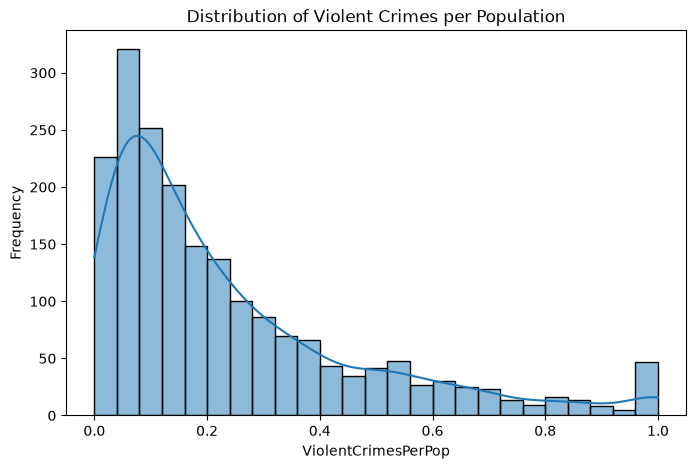

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True)
plt.title("Distribution of Violent Crimes per Population")
plt.xlabel("ViolentCrimesPerPop")
plt.ylabel("Frequency")
plt.show()

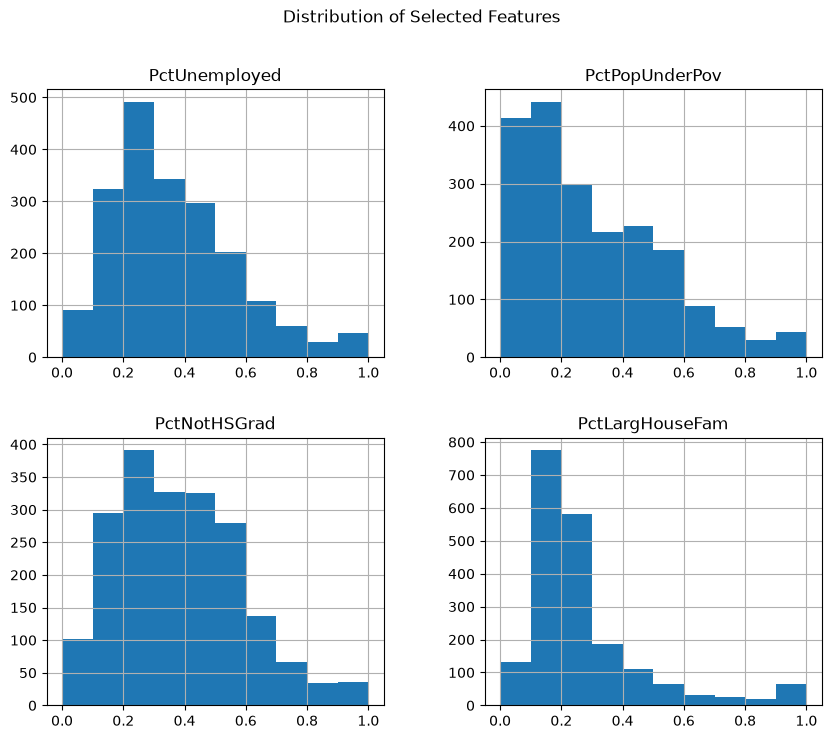

In [14]:
features_to_plot = [
    "PctUnemployed",
    "PctPopUnderPov",
    "PctNotHSGrad",
    "PctLargHouseFam"
]

X[features_to_plot].hist(figsize=(10, 8))
plt.suptitle("Distribution of Selected Features")
plt.show()

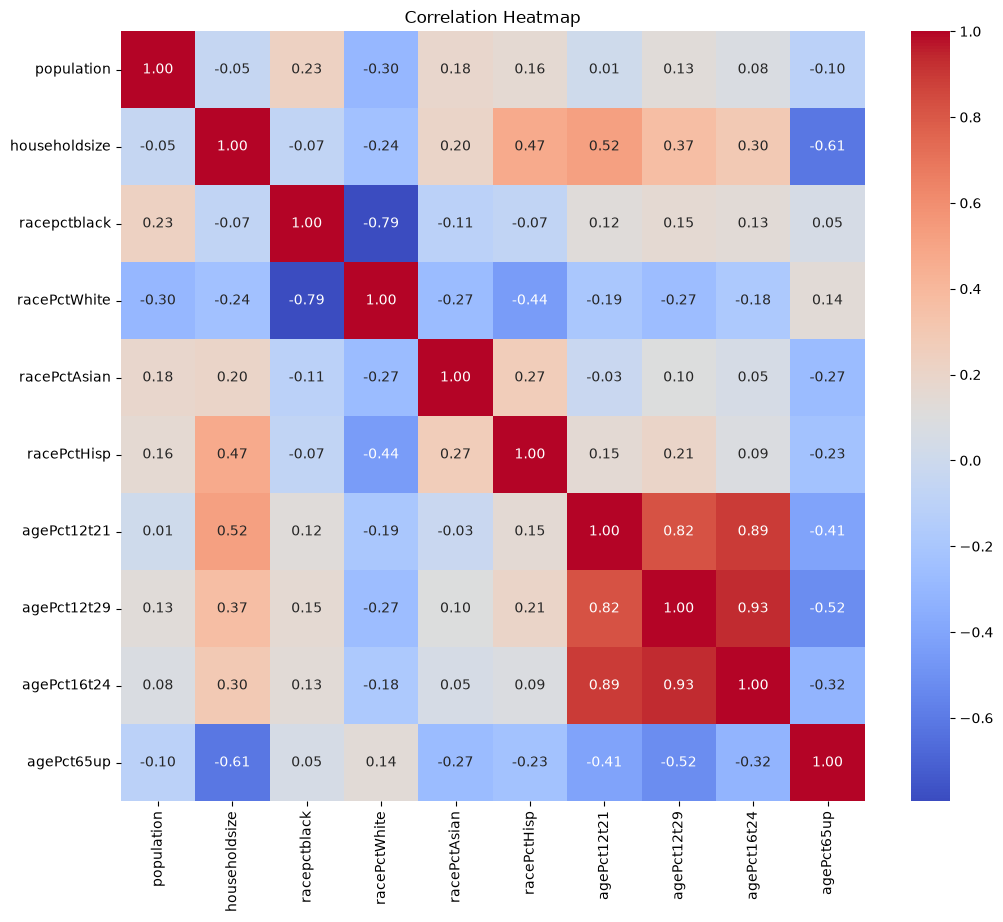

In [15]:
corr_data = pd.concat([X, y], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_data.corr(numeric_only=True).iloc[:10, :10],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

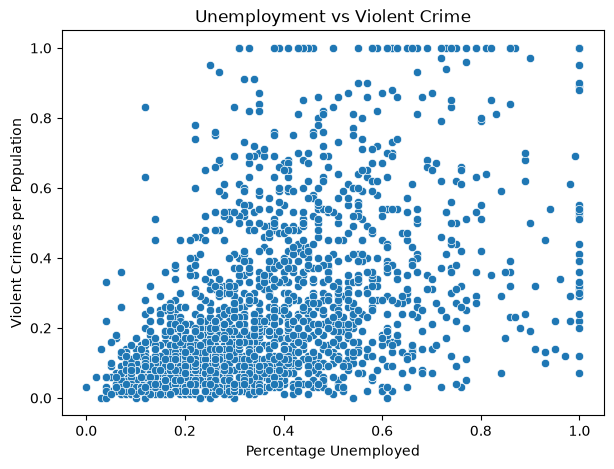

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["PctUnemployed"], y=y)
plt.title("Unemployment vs Violent Crime")
plt.xlabel("Percentage Unemployed")
plt.ylabel("Violent Crimes per Population")
plt.show()

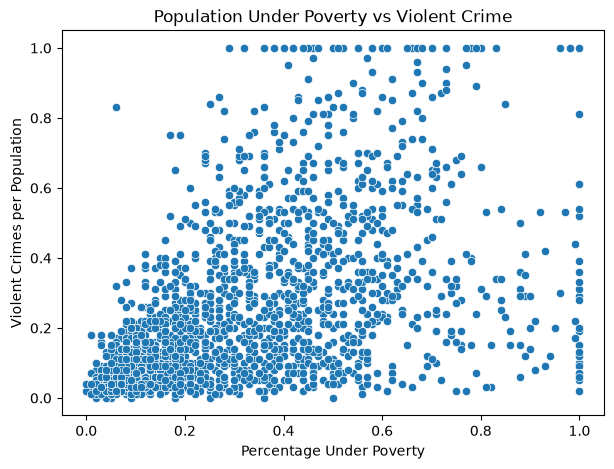

In [17]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["PctPopUnderPov"], y=y)
plt.title("Population Under Poverty vs Violent Crime")
plt.xlabel("Percentage Under Poverty")
plt.ylabel("Violent Crimes per Population")
plt.show()

In [18]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 1. Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)


# 2. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)


# 3. Lasso Regression
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)


# 4. ElasticNet Regression
elastic_model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred = elastic_model.predict(X_test_scaled)


# 5. Polynomial Regression
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)


print("All 5 regression models trained successfully.")
print("Polynomial features:", X_train_poly.shape)

All 5 regression models trained successfully.
Polynomial features: (1595, 7749)


In [29]:
results = []

predictions = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "ElasticNet Regression": elastic_pred,
    "Polynomial Regression": poly_pred
}

for name, pred in predictions.items():

    results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("R2", ascending=False)

,Model,R2,RMSE,MAE
2,Lasso Regression,0.635564,0.132117,0.091230
3,ElasticNet Regression,0.631498,0.132852,0.091868
1,Ridge Regression,0.622387,0.134484,0.094349
0,Linear Regression,0.621685,0.134609,0.094555
4,Polynomial Regression,-0.726984,0.287603,0.201295


In [30]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=3,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge parameters:")
print(ridge_grid.best_params_)

print("Best Ridge CV R2:")
print(ridge_grid.best_score_)

Best Ridge parameters:
{'alpha': 100}
Best Ridge CV R2:
0.6470473963288154


In [31]:
elastic = ElasticNet(
    alpha=0.001,
    max_iter=10000
)

elastic_params = {
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=3,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

print("Best ElasticNet parameters:")
print(elastic_grid.best_params_)

print("Best ElasticNet CV R2:")
print(elastic_grid.best_score_)

Best ElasticNet parameters:
{'l1_ratio': 0.9}
Best ElasticNet CV R2:
0.6443163810507108


In [32]:
lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train.columns
)

zero_coefficients = (lasso_coefficients == 0).sum()
total_coefficients = len(lasso_coefficients)

print("Total features:", total_coefficients)
print("Features with zero coefficient:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    round(zero_coefficients / total_coefficients * 100, 2),
    "%"
)

Total features: 123
Features with zero coefficient: 50
Percentage of zero coefficients: 40.65 %


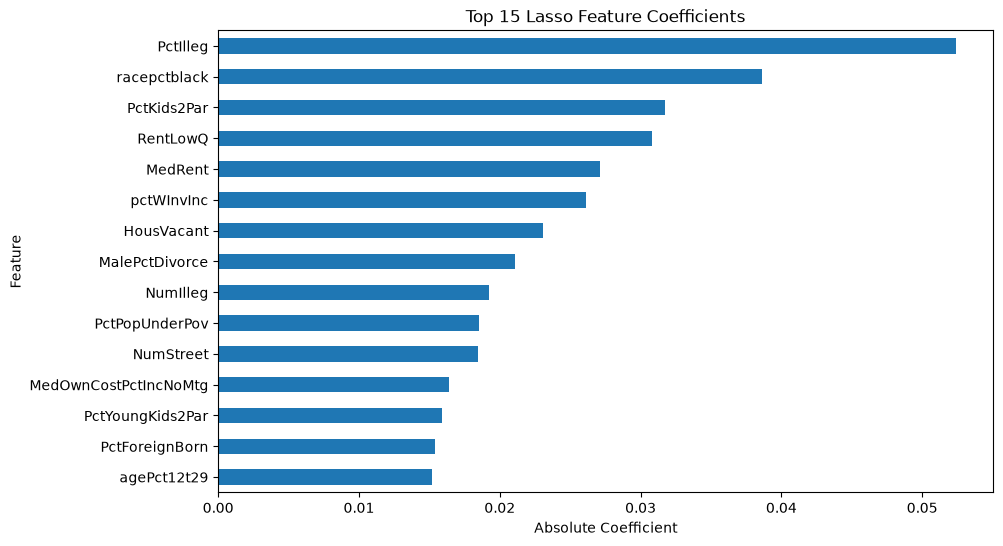

In [33]:
top_lasso = lasso_coefficients.abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
top_lasso.sort_values().plot(kind="barh")

plt.title("Top 15 Lasso Feature Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

In [34]:
linear_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train.columns
)

linear_coefficients.sort_values(
    key=abs,
    ascending=False
).head(15)

PctRecImmig8           0.128946
PersPerOccupHous       0.123262
TotalPctDiv           -0.122131
PctPersOwnOccup       -0.092166
MalePctDivorce         0.089292
PctRecImmig10         -0.087783
whitePerCap           -0.076910
MedRent                0.072067
medFamInc              0.064751
RentLowQ              -0.054883
PctLargHouseOccup     -0.054194
PctHousOwnOcc          0.052224
numbUrban             -0.046391
PctNotSpeakEnglWell   -0.044626
LemasSwornFT          -0.044088
dtype: float64

In [35]:
poly_results = []

for degree in [1, 2]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_p = poly.fit_transform(X_train_scaled)
    X_test_p = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_p, y_train)

    pred = model.predict(X_test_p)

    poly_results.append({
        "Degree": degree,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

pd.DataFrame(poly_results)

,Degree,R2,RMSE,MAE
0,1,0.621685,0.134609,0.094555
1,2,-0.726984,0.287603,0.201295


In [36]:
# Final Polynomial Regression using the better degree

best_degree = 1

poly_final = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

X_train_poly = poly_final.fit_transform(X_train_scaled)
X_test_poly = poly_final.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

print("Selected polynomial degree:", best_degree)
print("R2:", r2_score(y_test, poly_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
print("MAE:", mean_absolute_error(y_test, poly_pred))

Selected polynomial degree: 1
R2: 0.6216851044922312
RMSE: 0.13460934023480015
MAE: 0.09455488261109622


In [37]:
# Final results for all 5 regression models

final_predictions = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "ElasticNet Regression": elastic_pred,
    "Polynomial Regression": poly_pred
}

final_results = []

for name, pred in final_predictions.items():
    final_results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values("R2", ascending=False)

,Model,R2,RMSE,MAE
2,Lasso Regression,0.635564,0.132117,0.091230
3,ElasticNet Regression,0.631498,0.132852,0.091868
1,Ridge Regression,0.622387,0.134484,0.094349
0,Linear Regression,0.621685,0.134609,0.094555
4,Polynomial Regression,0.621685,0.134609,0.094555


In [38]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=3,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)

Best Ridge parameters: {'alpha': 100}
Best Ridge CV R2: 0.6470473963288154


In [39]:
elastic = ElasticNet(
    alpha=0.001,
    max_iter=10000
)

elastic_params = {
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=3,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

print("Best ElasticNet parameters:", elastic_grid.best_params_)
print("Best ElasticNet CV R2:", elastic_grid.best_score_)

Best ElasticNet parameters: {'l1_ratio': 0.9}
Best ElasticNet CV R2: 0.6443163810507108


In [40]:
from sklearn.model_selection import cross_val_score

# Best two models from our initial test results
best_lasso = lasso_model
best_elastic = elastic_grid.best_estimator_

# 5-fold CV
lasso_cv = cross_val_score(
    best_lasso,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

elastic_cv = cross_val_score(
    best_elastic,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Lasso 5-Fold CV R2:")
print(lasso_cv)
print("Mean:", lasso_cv.mean())

print("\nElasticNet 5-Fold CV R2:")
print(elastic_cv)
print("Mean:", elastic_cv.mean())

Lasso 5-Fold CV R2:
[0.66604907 0.64267142 0.64574818 0.66841488 0.61295042]
Mean: 0.647166796432719

ElasticNet 5-Fold CV R2:
[0.66553795 0.6427686  0.64657279 0.66807579 0.6118411 ]
Mean: 0.6469592449958843


In [41]:
# Lasso Feature Sparsity

lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train.columns
)

zero_coefficients = (lasso_coefficients == 0).sum()
total_coefficients = len(lasso_coefficients)

print("Total features:", total_coefficients)
print("Features with zero coefficient:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    round(zero_coefficients / total_coefficients * 100, 2),
    "%"
)


Total features: 123
Features with zero coefficient: 50
Percentage of zero coefficients: 40.65 %


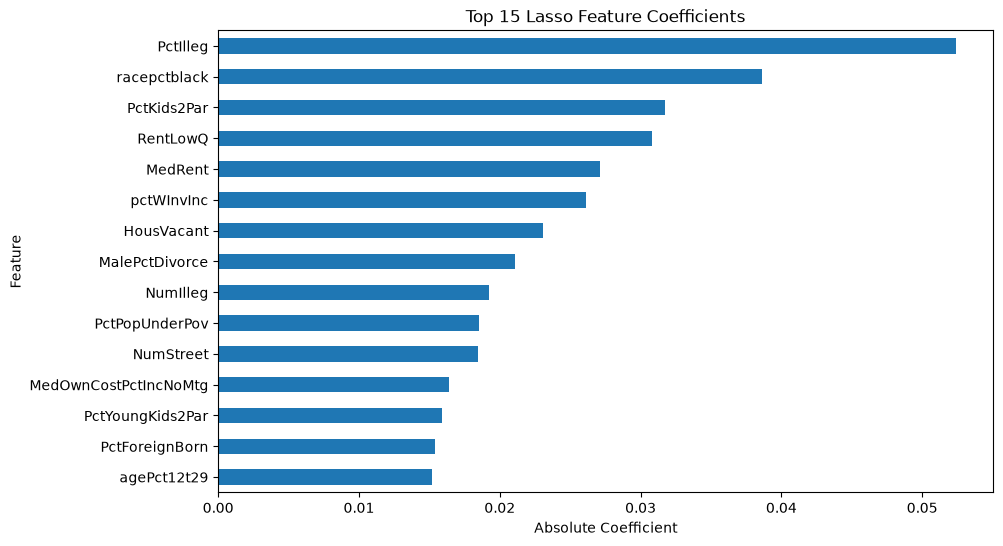

In [42]:
# Top Lasso coefficients

top_lasso = lasso_coefficients.abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
top_lasso.sort_values().plot(kind="barh")

plt.title("Top 15 Lasso Feature Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

In [43]:
# Linear Regression coefficients

linear_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train.columns
)

print("Top 15 Linear Regression coefficients:")
print(
    linear_coefficients
    .sort_values(key=abs, ascending=False)
    .head(15)
)


Top 15 Linear Regression coefficients:
PctRecImmig8           0.128946
PersPerOccupHous       0.123262
TotalPctDiv           -0.122131
PctPersOwnOccup       -0.092166
MalePctDivorce         0.089292
PctRecImmig10         -0.087783
whitePerCap           -0.076910
MedRent                0.072067
medFamInc              0.064751
RentLowQ              -0.054883
PctLargHouseOccup     -0.054194
PctHousOwnOcc          0.052224
numbUrban             -0.046391
PctNotSpeakEnglWell   -0.044626
LemasSwornFT          -0.044088
dtype: float64


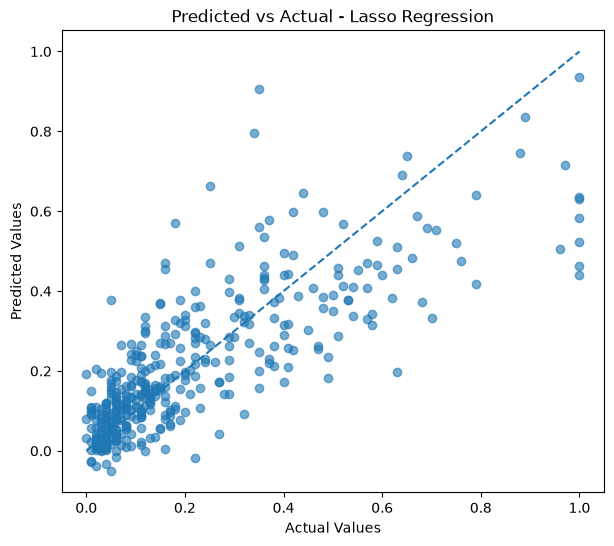

In [44]:
# Predicted vs Actual - Lasso

best_model = lasso_model
best_pred = lasso_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))

plt.scatter(y_test, best_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Predicted vs Actual - Lasso Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

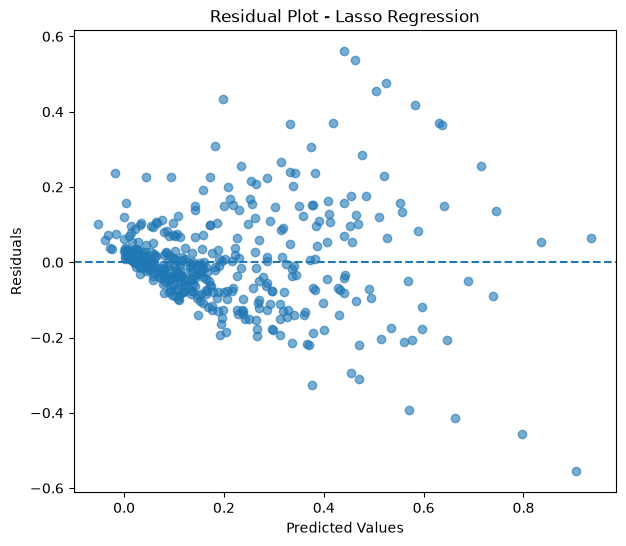

In [45]:
# Residual Plot - Lasso

residuals = y_test - best_pred

plt.figure(figsize=(7, 6))

plt.scatter(best_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Lasso Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()